# Wine Quality Prediction

This notebook uses one cleaned dataset and one shared train/validation/test split across the supervised models. The validation set is used for model selection; the test set is used only once at the end to estimate generalization.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.linear_model import Lasso, LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, PolynomialFeatures, StandardScaler

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")


def log1p_nonnegative(X):
    return np.log1p(np.maximum(np.asarray(X, dtype=float), 0.0))


## Load And Clean Data


In [2]:
candidate_csvs = [
    Path("WineQT.csv"),
    Path("wine+quality (1)/winequality-red.csv"),
    Path("../Wine-Pred/wine+quality (1)/winequality-red.csv"),
    Path("Wine-Pred/wine+quality (1)/winequality-red.csv"),
]

csv_path = next((path for path in candidate_csvs if path.exists()), None)
if csv_path is None:
    import kagglehub

    dataset_path = Path(kagglehub.dataset_download("yasserh/wine-quality-dataset"))
    csv_path = next(dataset_path.rglob("*.csv"))

df = pd.read_csv(csv_path, sep=None, engine="python")
df.columns = df.columns.str.strip().str.replace(" ", "_")

if "Id" in df.columns:
    df = df.drop(columns="Id")

df = df.fillna(df.median(numeric_only=True))

feature_cols = [col for col in df.columns if col != "quality"]
X_all = df[feature_cols].astype(float)
y_quality = df["quality"].astype(float)

# Three quality buckets for classification: bad (<5), medium (5-6), good (>=7).
y_bucket = np.select(
    [y_quality < 5, (y_quality >= 5) & (y_quality < 7), y_quality >= 7],
    [0, 1, 2],
)
class_labels = ["bad", "medium", "good"]

print("Using CSV:", csv_path)
print("Shape:", df.shape)
display(df.head())
display(df["quality"].value_counts().sort_index().rename("count").to_frame())


Using CSV: ../Wine-Pred/wine+quality (1)/winequality-red.csv
Shape: (1599, 12)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


,count
quality,
3,10
4,53
5,681
6,638
7,199
8,18


## Exploratory Data Analysis


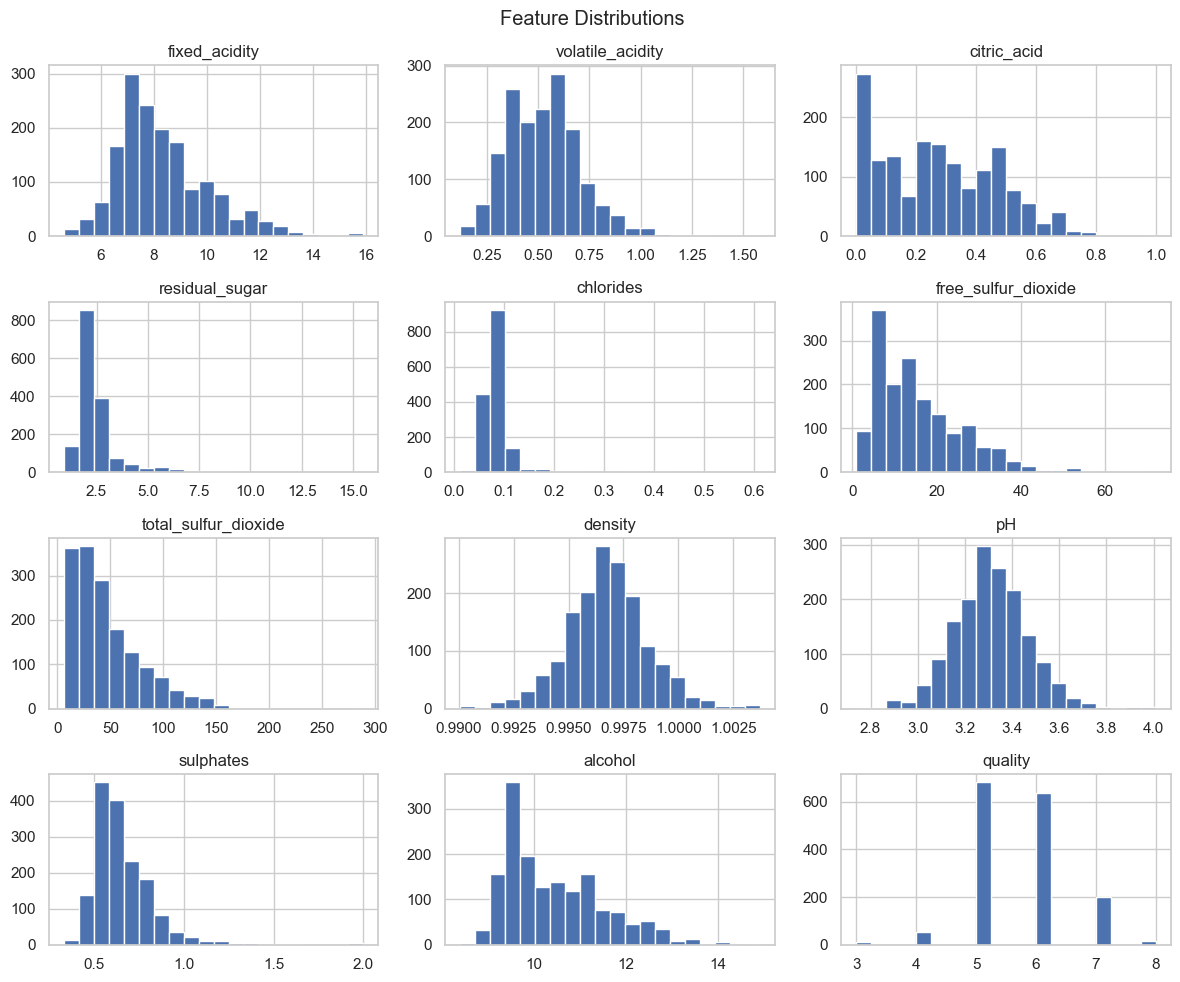

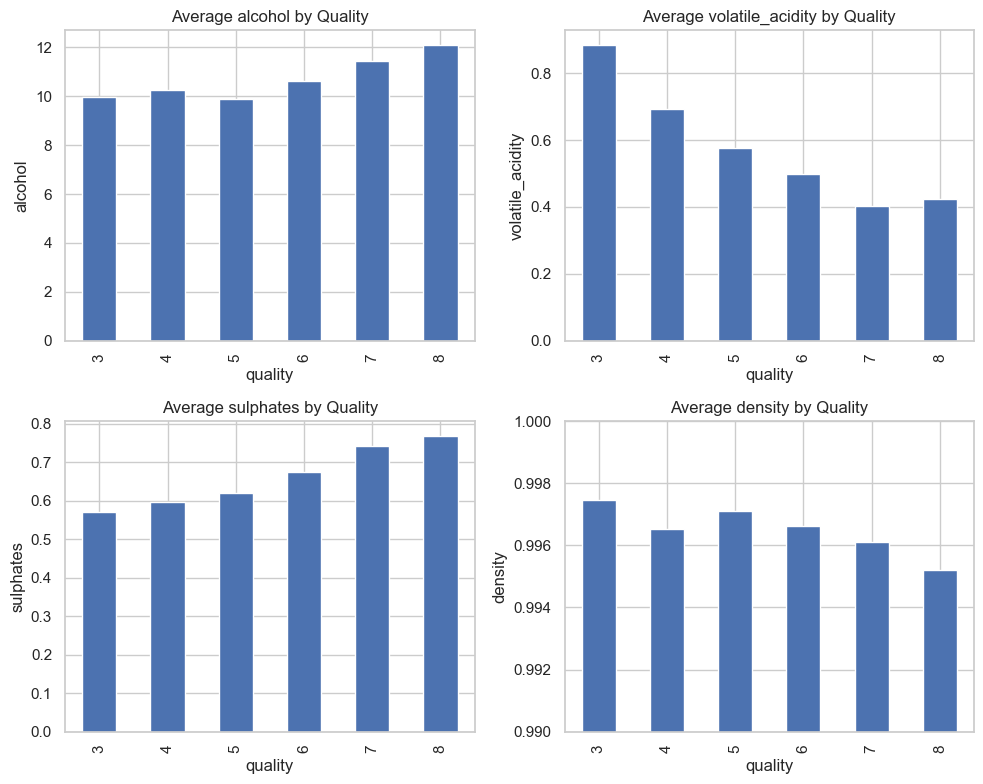

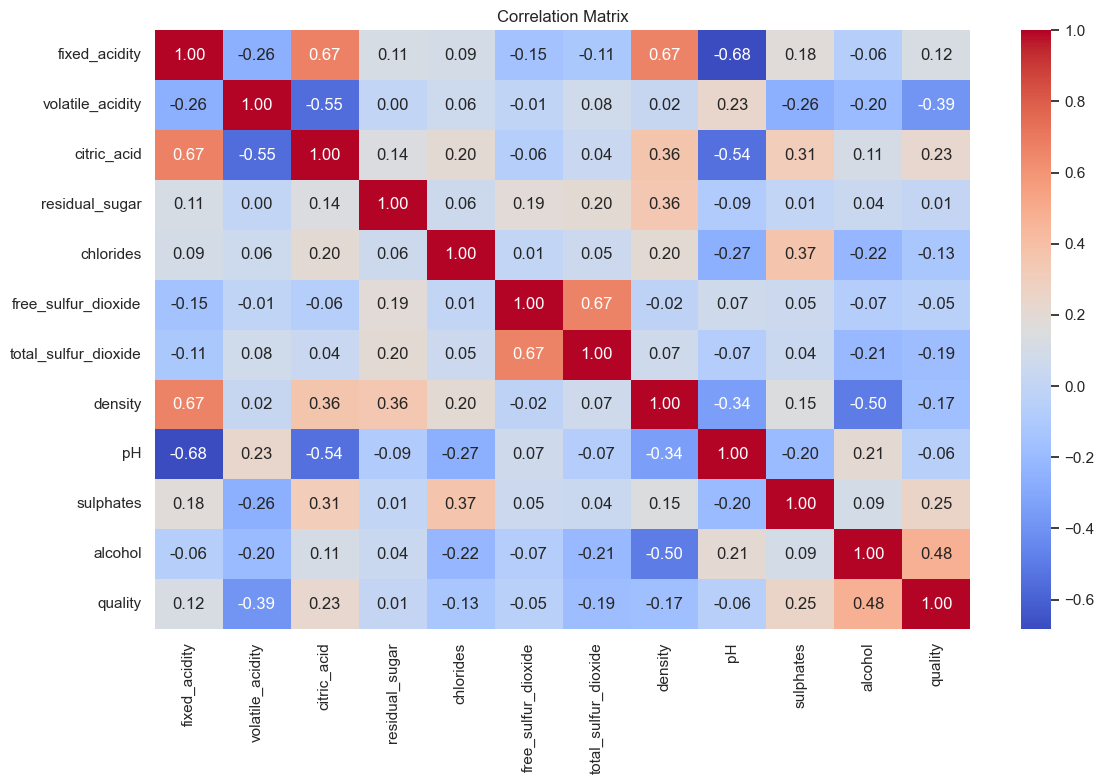

In [3]:
df[feature_cols + ["quality"]].hist(figsize=(12, 10), bins=20)
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

important_features = ["alcohol", "volatile_acidity", "sulphates", "density"]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, feature in zip(axes.ravel(), important_features):
    df.groupby("quality")[feature].mean().plot(kind="bar", ax=ax)
    ax.set_title(f"Average {feature} by Quality")
    ax.set_xlabel("quality")
    ax.set_ylabel(feature)
    if feature == "density":
        ax.set_ylim(0.99, 1.00)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(df[feature_cols + ["quality"]].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


## Shared Split

The models below use the same 60/20/20 split. Hyperparameters are chosen on validation data; final generalization is evaluated on the held-out test data.


In [4]:
X_train_val, X_test, y_train_val_cls, y_test_cls, y_train_val_reg, y_test_reg = train_test_split(
    X_all,
    y_bucket,
    y_quality,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_bucket,
)

X_train, X_val, y_train_cls, y_val_cls, y_train_reg, y_val_reg = train_test_split(
    X_train_val,
    y_train_val_cls,
    y_train_val_reg,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_train_val_cls,
)

split_summary = pd.DataFrame(
    {
        "rows": [len(X_train), len(X_val), len(X_test)],
        "classification_classes": [
            dict(zip(*np.unique(y, return_counts=True)))
            for y in [y_train_cls, y_val_cls, y_test_cls]
        ],
    },
    index=["train", "validation", "test"],
)
display(split_summary)


,rows,classification_classes
train,959,"{0: 38, 1: 791, 2: 130}"
validation,320,"{0: 12, 1: 264, 2: 44}"
test,320,"{0: 13, 1: 264, 2: 43}"


## Optional Clustering Check


,alcohol,volatile_acidity,sulphates,density,quality
cluster,,,,,
0,9.82,0.61,0.57,1.00,5.26
1,11.79,0.45,0.67,0.99,6.20
2,10.26,0.42,0.84,1.00,5.85


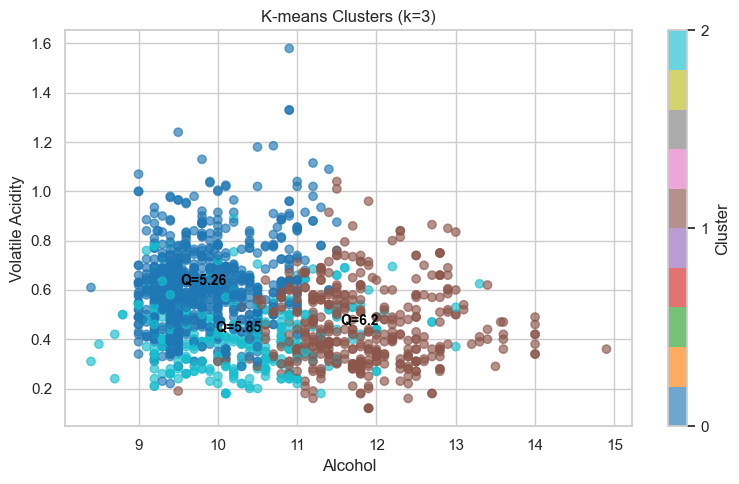

In [5]:
cluster_features = ["alcohol", "volatile_acidity", "sulphates", "density"]
cluster_scaler = StandardScaler()
X_cluster = cluster_scaler.fit_transform(df[cluster_features])

kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)

cluster_profile = (
    df.assign(cluster=cluster_labels)
    .groupby("cluster")[cluster_features + ["quality"]]
    .mean()
    .round(2)
)
display(cluster_profile)

fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    df["alcohol"],
    df["volatile_acidity"],
    c=cluster_labels,
    cmap="tab10",
    alpha=0.65,
)
fig.colorbar(scatter, ax=ax, label="Cluster", ticks=[0, 1, 2])
ax.set_xlabel("Alcohol")
ax.set_ylabel("Volatile Acidity")
ax.set_title("K-means Clusters (k=3)")
for cluster_id, row in cluster_profile.iterrows():
    ax.text(
        row["alcohol"],
        row["volatile_acidity"],
        f"Q={row['quality']}",
        fontsize=10,
        fontweight="bold",
        ha="center",
        va="bottom",
        color="black",
    )
plt.tight_layout()
plt.show()


## KNN Classification


,variant,k,train_accuracy,train_precision_weighted,train_recall_weighted,val_accuracy,val_precision_weighted,val_recall_weighted
0,scaled,1,1.0000,1.0000,1.0000,0.8250,0.8351,0.8250
1,scaled,3,0.8947,0.8880,0.8947,0.8344,0.8249,0.8344
2,scaled,5,0.8676,0.8513,0.8676,0.8312,0.8009,0.8312
3,scaled,7,0.8561,0.8305,0.8561,0.8469,0.8116,0.8469
4,scaled,9,0.8405,0.7969,0.8405,0.8438,0.8075,0.8438
5,scaled,11,0.8425,0.7962,0.8425,0.8531,0.8146,0.8531
6,poly2_scaled,1,1.0000,1.0000,1.0000,0.8500,0.8509,0.8500
7,poly2_scaled,3,0.9020,0.8945,0.9020,0.8406,0.8165,0.8406
8,poly2_scaled,5,0.8582,0.8422,0.8582,0.8344,0.8067,0.8344
9,poly2_scaled,7,0.8582,0.8411,0.8582,0.8500,0.8156,0.8500


Best KNN: poly2_scaled with k=9 and validation accuracy=0.859


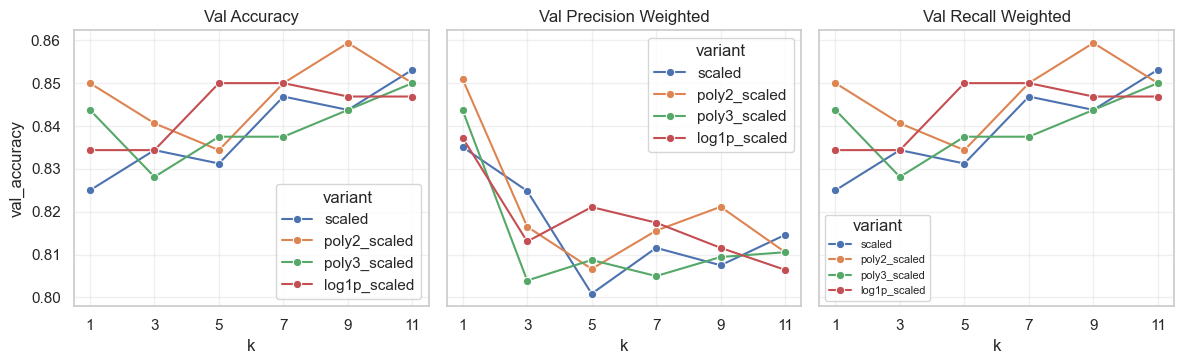

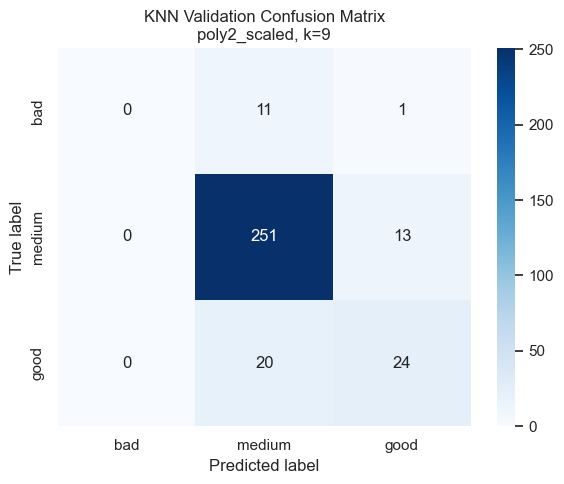

In [6]:
def classification_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
    }


def evaluate_knn_variant(name, transformer, k_values):
    X_train_variant = transformer.fit_transform(X_train)
    X_val_variant = transformer.transform(X_val)
    rows = []
    fitted = {}

    for k in k_values:
        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X_train_variant, y_train_cls)
        train_pred = model.predict(X_train_variant)
        val_pred = model.predict(X_val_variant)
        rows.append(
            {
                "variant": name,
                "k": k,
                **{f"train_{key}": value for key, value in classification_metrics(y_train_cls, train_pred).items()},
                **{f"val_{key}": value for key, value in classification_metrics(y_val_cls, val_pred).items()},
            }
        )
        fitted[k] = model

    return pd.DataFrame(rows), transformer, fitted

k_values = [1, 3, 5, 7, 9, 11]
knn_variants = {
    "scaled": make_pipeline(StandardScaler()),
    "poly2_scaled": make_pipeline(PolynomialFeatures(degree=2, include_bias=False), StandardScaler()),
    "poly3_scaled": make_pipeline(PolynomialFeatures(degree=3, include_bias=False), StandardScaler()),
    "log1p_scaled": make_pipeline(FunctionTransformer(log1p_nonnegative, validate=False), StandardScaler()),
}

knn_tables = []
knn_transformers = {}
knn_models = {}
for name, transformer in knn_variants.items():
    table, fitted_transformer, fitted_models = evaluate_knn_variant(name, transformer, k_values)
    knn_tables.append(table)
    knn_transformers[name] = fitted_transformer
    knn_models[name] = fitted_models

knn_results_df = pd.concat(knn_tables, ignore_index=True)
knn_best = knn_results_df.loc[knn_results_df["val_accuracy"].idxmax()]
display(knn_results_df.round(4))
print(f"Best KNN: {knn_best['variant']} with k={int(knn_best['k'])} and validation accuracy={knn_best['val_accuracy']:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
for ax, metric in zip(axes, ["val_accuracy", "val_precision_weighted", "val_recall_weighted"]):
    sns.lineplot(data=knn_results_df, x="k", y=metric, hue="variant", marker="o", ax=ax)
    ax.set_title(metric.replace("_", " ").title())
    ax.set_xticks(k_values)
    ax.grid(True, alpha=0.3)
axes[-1].legend(fontsize=8, title="variant")
plt.tight_layout()
plt.show()

best_knn_transformer = knn_transformers[knn_best["variant"]]
best_knn_model = knn_models[knn_best["variant"]][int(knn_best["k"])]
y_val_pred_knn = best_knn_model.predict(best_knn_transformer.transform(X_val))

cm_knn = confusion_matrix(y_val_cls, y_val_pred_knn, labels=[0, 1, 2])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues", ax=ax, xticklabels=class_labels, yticklabels=class_labels)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title(f"KNN Validation Confusion Matrix\n{knn_best['variant']}, k={int(knn_best['k'])}")
plt.tight_layout()
plt.show()


## Logistic Regression Classification


,penalty,C,train_accuracy,train_precision_weighted,train_recall_weighted,val_accuracy,val_precision_weighted,val_recall_weighted
0,l2,0.01,0.8332,0.7844,0.8332,0.8344,0.7888,0.8344
1,l2,0.10,0.8394,0.8095,0.8394,0.8469,0.8011,0.8469
2,l2,0.50,0.8405,0.8146,0.8405,0.8438,0.8023,0.8438
3,l2,1.00,0.8415,0.8162,0.8415,0.8438,0.8023,0.8438
4,l2,10.00,0.8415,0.8162,0.8415,0.8438,0.8023,0.8438
5,l2,100.00,0.8425,0.8178,0.8425,0.8438,0.8023,0.8438
6,l1,0.01,0.8248,0.6803,0.8248,0.8250,0.6806,0.8250
7,l1,0.10,0.8405,0.8287,0.8405,0.8562,0.8143,0.8562
8,l1,0.50,0.8405,0.8111,0.8405,0.8531,0.8097,0.8531
9,l1,1.00,0.8394,0.8133,0.8394,0.8438,0.8023,0.8438


Best Logistic Regression: L1 with C=0.1 and validation accuracy=0.856


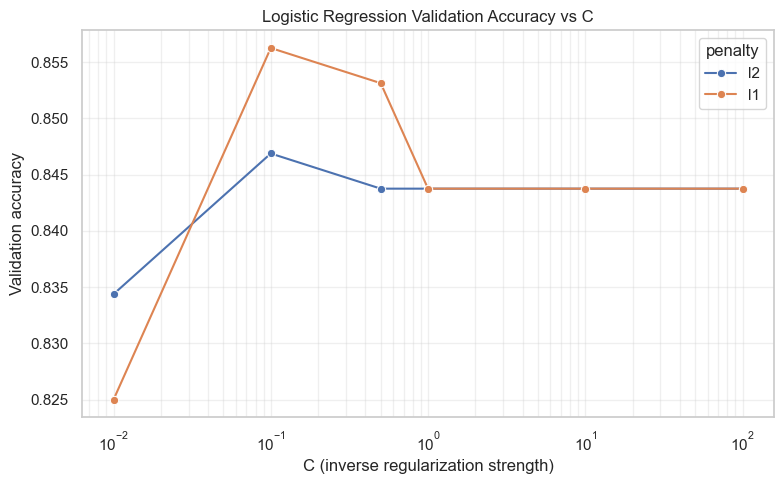

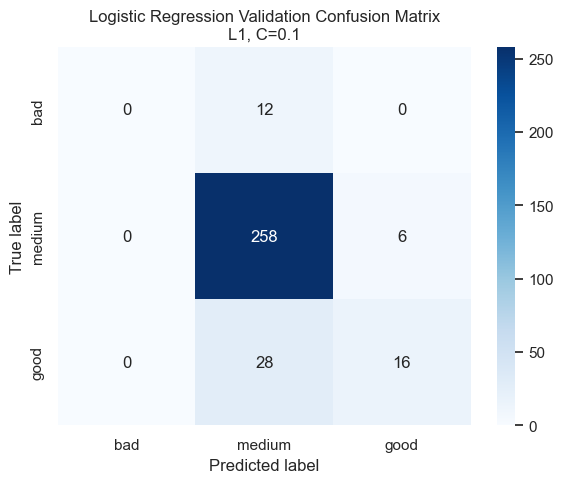

In [7]:
logistic_scaler = StandardScaler()
X_train_logistic = logistic_scaler.fit_transform(X_train)
X_val_logistic = logistic_scaler.transform(X_val)

C_values = [0.01, 0.1, 0.5, 1.0, 10.0, 100.0]
logistic_rows = []
logistic_models = {}

for penalty_label, solver, l1_ratio in [("l2", "lbfgs", 0.0), ("l1", "saga", 1.0)]:
    for C in C_values:
        model = LogisticRegression(
            C=C,
            l1_ratio=l1_ratio,
            solver=solver,
            max_iter=10000,
            random_state=RANDOM_STATE,
        )
        model.fit(X_train_logistic, y_train_cls)
        train_pred = model.predict(X_train_logistic)
        val_pred = model.predict(X_val_logistic)
        logistic_rows.append(
            {
                "penalty": penalty_label,
                "C": C,
                **{f"train_{key}": value for key, value in classification_metrics(y_train_cls, train_pred).items()},
                **{f"val_{key}": value for key, value in classification_metrics(y_val_cls, val_pred).items()},
            }
        )
        logistic_models[(penalty_label, C)] = model

logistic_results_df = pd.DataFrame(logistic_rows)
logistic_best = logistic_results_df.loc[logistic_results_df["val_accuracy"].idxmax()]
display(logistic_results_df.round(4))
print(
    f"Best Logistic Regression: {logistic_best['penalty'].upper()} with "
    f"C={logistic_best['C']:g} and validation accuracy={logistic_best['val_accuracy']:.3f}"
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=logistic_results_df, x="C", y="val_accuracy", hue="penalty", marker="o", ax=ax)
ax.set_xscale("log")
ax.set_xlabel("C (inverse regularization strength)")
ax.set_ylabel("Validation accuracy")
ax.set_title("Logistic Regression Validation Accuracy vs C")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

best_logistic_model = logistic_models[(logistic_best["penalty"], logistic_best["C"])]
y_val_pred_logistic = best_logistic_model.predict(X_val_logistic)
cm_logistic = confusion_matrix(y_val_cls, y_val_pred_logistic, labels=[0, 1, 2])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_logistic, annot=True, fmt="d", cmap="Blues", ax=ax, xticklabels=class_labels, yticklabels=class_labels)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title(
    f"Logistic Regression Validation Confusion Matrix\n"
    f"{logistic_best['penalty'].upper()}, C={logistic_best['C']:g}"
)
plt.tight_layout()
plt.show()


## Linear Regression And Regularization


,model,hyperparameter,train_mse,val_mse,train_rmse,val_rmse,train_r2,val_r2,train_rounded_accuracy,val_rounded_accuracy
0,Ridge,alpha=100,0.4193,0.4107,0.6476,0.6408,0.3603,0.3610,0.5871,0.5906
1,Lasso,alpha=0.01,0.4201,0.4113,0.6482,0.6413,0.3591,0.3601,0.5912,0.5906
2,Ridge,alpha=10,0.4174,0.4123,0.6461,0.6421,0.3632,0.3585,0.5954,0.6062
3,Ridge,alpha=1,0.4174,0.4128,0.6461,0.6425,0.3632,0.3578,0.5954,0.6062
4,Ridge,alpha=0.5,0.4174,0.4128,0.6461,0.6425,0.3632,0.3577,0.5954,0.6062
5,Ridge,alpha=0.1,0.4174,0.4128,0.6461,0.6425,0.3632,0.3577,0.5954,0.6062
6,Ridge,alpha=0.01,0.4174,0.4128,0.6461,0.6425,0.3632,0.3577,0.5954,0.6062
7,Linear Regression,none,0.4174,0.4128,0.6461,0.6425,0.3632,0.3577,0.5954,0.6062
8,Lasso,alpha=0.1,0.4579,0.4491,0.6767,0.6701,0.3015,0.3013,0.5819,0.5500
9,Lasso,alpha=0.5,0.6555,0.6429,0.8096,0.8018,0.0000,-0.0003,0.3952,0.3875


Best regression model by validation MSE: Ridge (alpha=100) with validation RMSE=0.641


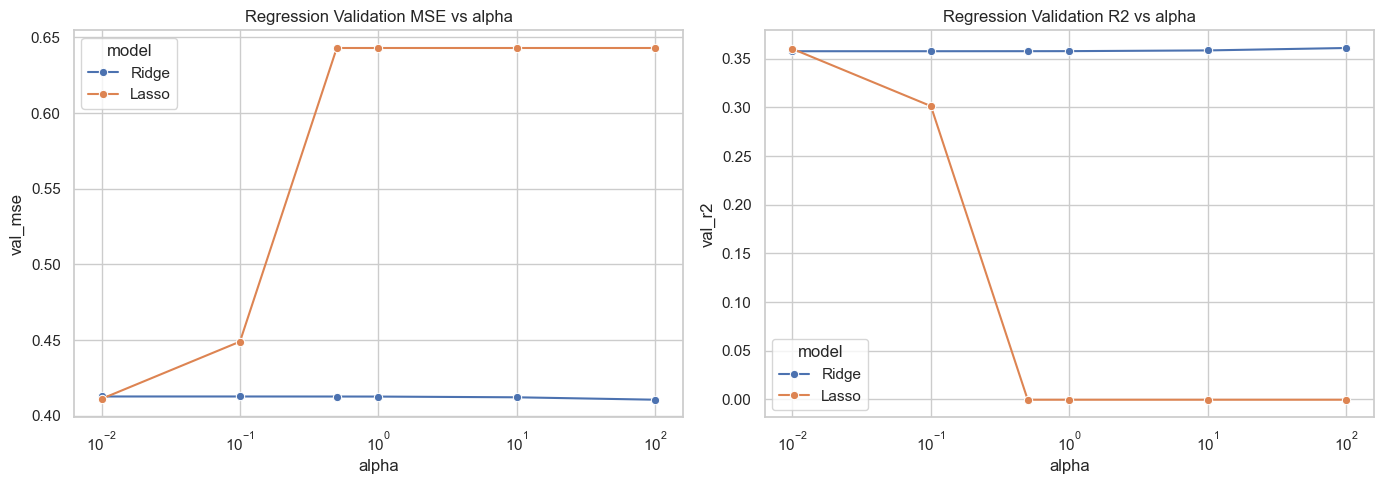

In [8]:
regression_scaler = StandardScaler()
X_train_reg_scaled = regression_scaler.fit_transform(X_train)
X_val_reg_scaled = regression_scaler.transform(X_val)

regression_rows = []
regression_models = {}
alpha_values = [0.01, 0.1, 0.5, 1, 10, 100]


def add_regression_result(model_name, hyperparameter, model):
    model.fit(X_train_reg_scaled, y_train_reg)
    train_pred = model.predict(X_train_reg_scaled)
    val_pred = model.predict(X_val_reg_scaled)
    train_mse = mean_squared_error(y_train_reg, train_pred)
    val_mse = mean_squared_error(y_val_reg, val_pred)
    regression_rows.append(
        {
            "model": model_name,
            "hyperparameter": hyperparameter,
            "train_mse": train_mse,
            "val_mse": val_mse,
            "train_rmse": np.sqrt(train_mse),
            "val_rmse": np.sqrt(val_mse),
            "train_r2": r2_score(y_train_reg, train_pred),
            "val_r2": r2_score(y_val_reg, val_pred),
            "train_rounded_accuracy": accuracy_score(y_train_reg, np.clip(np.rint(train_pred), 0, 10)),
            "val_rounded_accuracy": accuracy_score(y_val_reg, np.clip(np.rint(val_pred), 0, 10)),
        }
    )
    regression_models[(model_name, hyperparameter)] = model

add_regression_result("Linear Regression", "none", LinearRegression())
for alpha in alpha_values:
    add_regression_result("Ridge", f"alpha={alpha:g}", Ridge(alpha=alpha))
    add_regression_result("Lasso", f"alpha={alpha:g}", Lasso(alpha=alpha, max_iter=20000))

regression_results_df = pd.DataFrame(regression_rows).sort_values("val_mse").reset_index(drop=True)
regression_best = regression_results_df.iloc[0]
display(regression_results_df.round(4))
print(
    f"Best regression model by validation MSE: {regression_best['model']} "
    f"({regression_best['hyperparameter']}) with validation RMSE={regression_best['val_rmse']:.3f}"
)

reg_plot_df = regression_results_df[regression_results_df["model"].isin(["Ridge", "Lasso"])].copy()
reg_plot_df["alpha"] = reg_plot_df["hyperparameter"].str.replace("alpha=", "", regex=False).astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
sns.lineplot(data=reg_plot_df, x="alpha", y="val_mse", hue="model", marker="o", ax=axes[0])
sns.lineplot(data=reg_plot_df, x="alpha", y="val_r2", hue="model", marker="o", ax=axes[1])
axes[0].set_title("Regression Validation MSE vs alpha")
axes[1].set_title("Regression Validation R2 vs alpha")
for ax in axes:
    ax.set_xscale("log")
    ax.set_xlabel("alpha")
plt.tight_layout()
plt.show()


## Regularization Effects


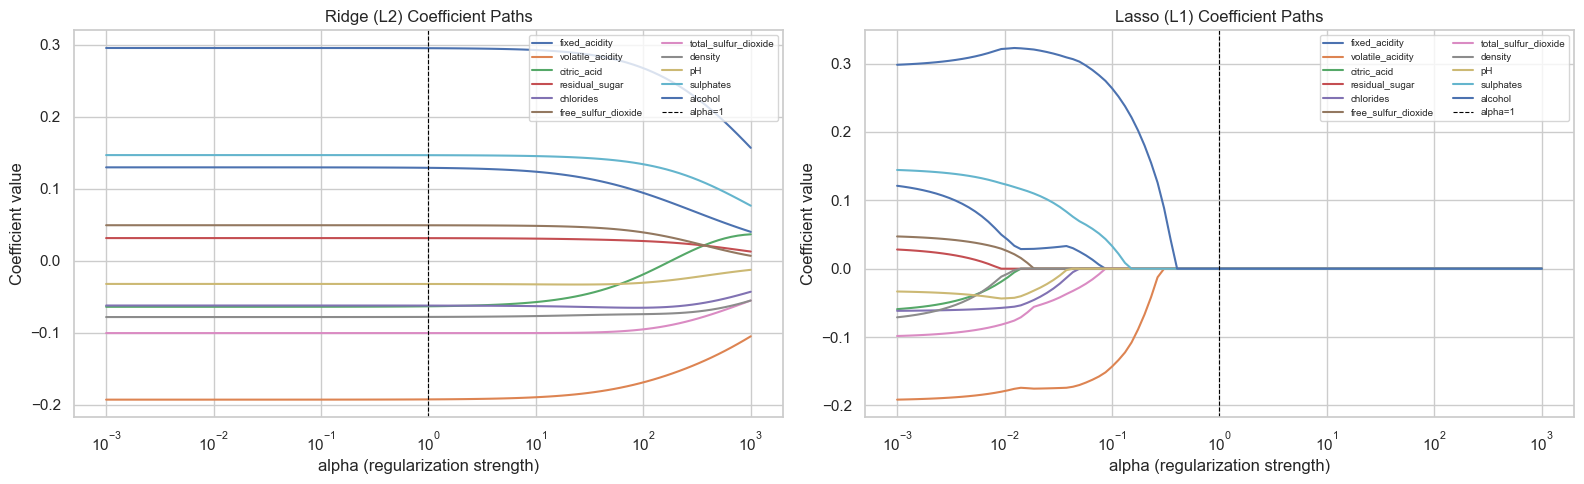

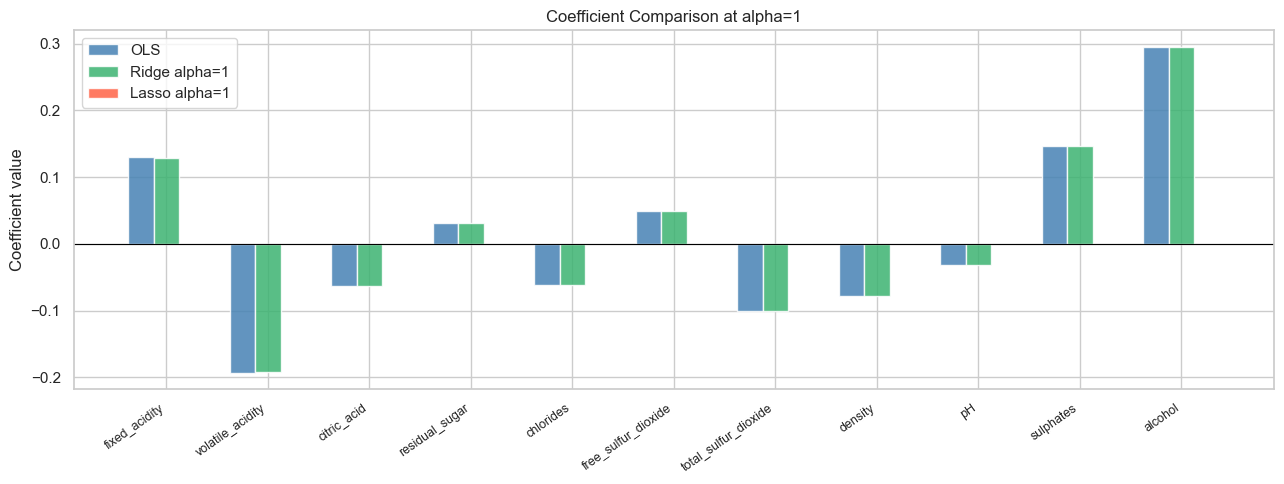

In [9]:
alphas = np.logspace(-3, 3, 100)
ridge_coefs = []
lasso_coefs = []

for alpha in alphas:
    ridge_coefs.append(Ridge(alpha=alpha).fit(X_train_reg_scaled, y_train_reg).coef_)
    lasso_coefs.append(Lasso(alpha=alpha, max_iter=20000).fit(X_train_reg_scaled, y_train_reg).coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for index, feature in enumerate(feature_cols):
    axes[0].plot(alphas, ridge_coefs[:, index], label=feature)
    axes[1].plot(alphas, lasso_coefs[:, index], label=feature)

axes[0].set_title("Ridge (L2) Coefficient Paths")
axes[1].set_title("Lasso (L1) Coefficient Paths")
for ax in axes:
    ax.set_xscale("log")
    ax.axvline(1.0, color="black", linestyle="--", linewidth=0.8, label="alpha=1")
    ax.set_xlabel("alpha (regularization strength)")
    ax.set_ylabel("Coefficient value")
    ax.legend(fontsize=7, loc="upper right", ncol=2)
plt.tight_layout()
plt.show()

ols_coef = LinearRegression().fit(X_train_reg_scaled, y_train_reg).coef_
ridge_coef = Ridge(alpha=1.0).fit(X_train_reg_scaled, y_train_reg).coef_
lasso_coef = Lasso(alpha=1.0, max_iter=20000).fit(X_train_reg_scaled, y_train_reg).coef_

x = np.arange(len(feature_cols))
width = 0.25
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width, ols_coef, width, label="OLS", color="steelblue", alpha=0.85)
ax.bar(x, ridge_coef, width, label="Ridge alpha=1", color="mediumseagreen", alpha=0.85)
ax.bar(x + width, lasso_coef, width, label="Lasso alpha=1", color="tomato", alpha=0.85)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(feature_cols, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Coefficient value")
ax.set_title("Coefficient Comparison at alpha=1")
ax.legend()
plt.tight_layout()
plt.show()


## Generalization On Held-Out Test Data


,model,accuracy,precision_weighted,recall_weighted,rmse,r2,rounded_accuracy
0,KNN,0.85,0.8070,0.85,NaN,NaN,NaN
1,Logistic Regression,0.85,0.8034,0.85,NaN,NaN,NaN
2,Ridge (alpha=100),NaN,NaN,NaN,0.6534,0.3418,0.5781


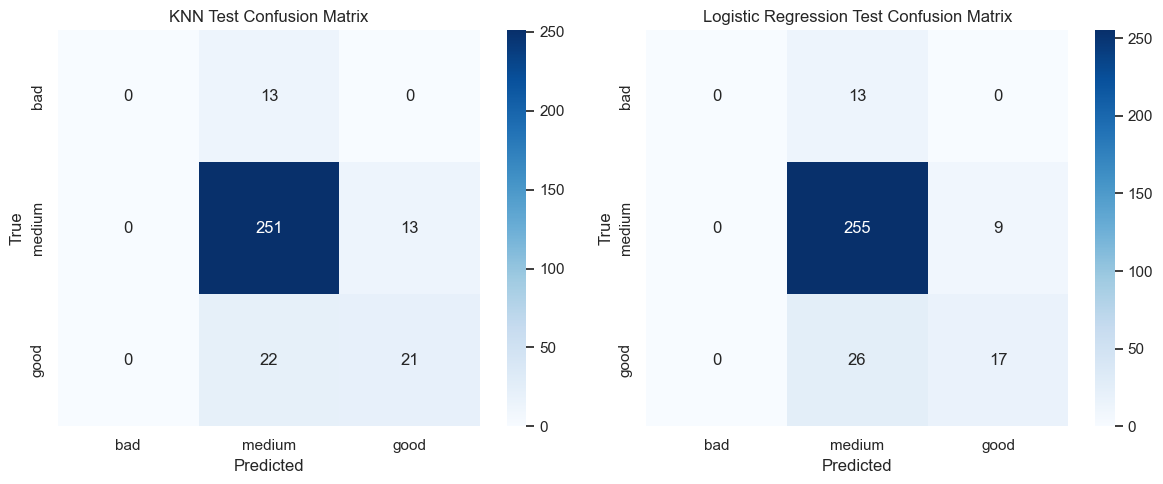

In [10]:
# Refit each selected model on train + validation, then evaluate once on the untouched test set.
X_train_val_full = pd.concat([X_train, X_val])
y_train_val_cls_full = np.concatenate([y_train_cls, y_val_cls])
y_train_val_reg_full = pd.concat([y_train_reg, y_val_reg])

generalization_rows = []

final_knn_transformer = knn_variants[knn_best["variant"]]
X_train_val_knn = final_knn_transformer.fit_transform(X_train_val_full)
X_test_knn = final_knn_transformer.transform(X_test)
final_knn = KNeighborsClassifier(n_neighbors=int(knn_best["k"]))
final_knn.fit(X_train_val_knn, y_train_val_cls_full)
test_pred_knn = final_knn.predict(X_test_knn)
generalization_rows.append({"model": "KNN", **classification_metrics(y_test_cls, test_pred_knn)})

final_logistic_scaler = StandardScaler()
X_train_val_logistic = final_logistic_scaler.fit_transform(X_train_val_full)
X_test_logistic = final_logistic_scaler.transform(X_test)
final_logistic = LogisticRegression(
    C=float(logistic_best["C"]),
    l1_ratio=1.0 if logistic_best["penalty"] == "l1" else 0.0,
    solver="saga" if logistic_best["penalty"] == "l1" else "lbfgs",
    max_iter=10000,
    random_state=RANDOM_STATE,
)
final_logistic.fit(X_train_val_logistic, y_train_val_cls_full)
test_pred_logistic = final_logistic.predict(X_test_logistic)
generalization_rows.append({"model": "Logistic Regression", **classification_metrics(y_test_cls, test_pred_logistic)})

final_regression_scaler = StandardScaler()
X_train_val_reg_scaled = final_regression_scaler.fit_transform(X_train_val_full)
X_test_reg_scaled = final_regression_scaler.transform(X_test)

best_reg_model_name = regression_best["model"]
best_reg_hyperparameter = regression_best["hyperparameter"]
if best_reg_model_name == "Linear Regression":
    final_regression = LinearRegression()
elif best_reg_model_name == "Ridge":
    final_regression = Ridge(alpha=float(best_reg_hyperparameter.split("=")[1]))
else:
    final_regression = Lasso(alpha=float(best_reg_hyperparameter.split("=")[1]), max_iter=20000)

final_regression.fit(X_train_val_reg_scaled, y_train_val_reg_full)
test_pred_reg = final_regression.predict(X_test_reg_scaled)
test_mse = mean_squared_error(y_test_reg, test_pred_reg)
generalization_rows.append(
    {
        "model": f"{best_reg_model_name} ({best_reg_hyperparameter})",
        "rmse": np.sqrt(test_mse),
        "r2": r2_score(y_test_reg, test_pred_reg),
        "rounded_accuracy": accuracy_score(y_test_reg, np.clip(np.rint(test_pred_reg), 0, 10)),
    }
)

generalization_df = pd.DataFrame(generalization_rows)
display(generalization_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(
    confusion_matrix(y_test_cls, test_pred_knn, labels=[0, 1, 2]),
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    xticklabels=class_labels,
    yticklabels=class_labels,
)
axes[0].set_title("KNN Test Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(
    confusion_matrix(y_test_cls, test_pred_logistic, labels=[0, 1, 2]),
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[1],
    xticklabels=class_labels,
    yticklabels=class_labels,
)
axes[1].set_title("Logistic Regression Test Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
plt.tight_layout()
plt.show()
